In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
words[:3]

['emma', 'olivia', 'ava']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [6]:
# Bigram (one character predicts the next one with a lookup table of counts)

# We only conside one char and not the whole char before it.
# ex.: we conside 'a' in 'isabella' and not 'isa' while trying to predict the whole name.
# Its a very simple model

In [7]:
for w in words[:1]:
    for ch1, ch2 in zip(w, w[1:]):
        print(ch1, ch2)

e m
m m
m a


In [8]:
w, list(w)

('emma', ['e', 'm', 'm', 'a'])

In [9]:
for w in words[:3]:
    chs = ['<START>'] + list(w) + ['<END>']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

<START> e
e m
m m
m a
a <END>
<START> o
o l
l i
i v
v i
i a
a <END>
<START> a
a v
v a
a <END>


In [10]:
b = {}
for w in words[:3]:
    chs = ['<START>'] + list(w) + ['<END>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        print(ch1, ch2)

<START> e
e m
m m
m a
a <END>
<START> o
o l
l i
i v
v i
i a
a <END>
<START> a
a v
v a
a <END>


In [11]:
b

{('<START>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<END>'): 3,
 ('<START>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<START>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [12]:
b = {}
for w in words:
    chs = ['<START>'] + list(w) + ['<END>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [13]:
sorted(b.items(), key = lambda kv: -kv[1])[:10]

[(('n', '<END>'), 6763),
 (('a', '<END>'), 6640),
 (('a', 'n'), 5438),
 (('<START>', 'a'), 4410),
 (('e', '<END>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<START>', 'k'), 2963)]

In [14]:
import torch

In [15]:
a = torch.zeros(3, 4)

In [16]:
a

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [17]:
a.dtype

torch.float32

In [18]:
a = torch.zeros((3, 4), dtype = torch.int32)

In [19]:
a

tensor([[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]], dtype=torch.int32)

In [20]:
a[1, 3] = 1

In [21]:
a

tensor([[0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 0]], dtype=torch.int32)

In [22]:
# we have 28 ch = 26 alphabets + <START> + <END>

In [23]:
N = torch.zeros((28, 28), dtype = torch.int32)

In [24]:
N

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [25]:
chars = sorted(set(''.join(words)))
stoi = {s:i for i, s in enumerate(chars)}
stoi['<START>'] = 26
stoi['<END>'] = 27
stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<START>': 26,
 '<END>': 27}

In [26]:
for w in words:
    chs = ['<START>'] + list(w) + ['<END>']
    for ch1, ch2 in zip(chs, chs[1:]):
      ich1 = stoi[ch1]
      ich2 = stoi[ch2]
      N[ich1, ich2] += 1

In [27]:
N

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

In [28]:
import matplotlib.pyplot as plt
%matplotlib inline

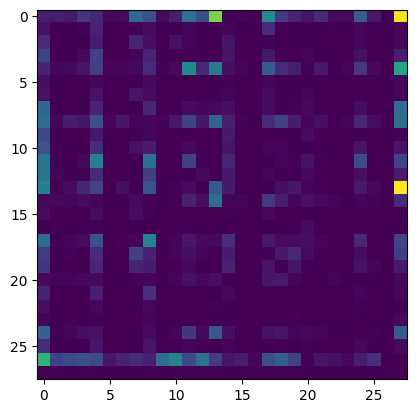

In [29]:
from matplotlib import legend
plt.imshow(N)

In [30]:
itos = {i:s for s, i in stoi.items()}

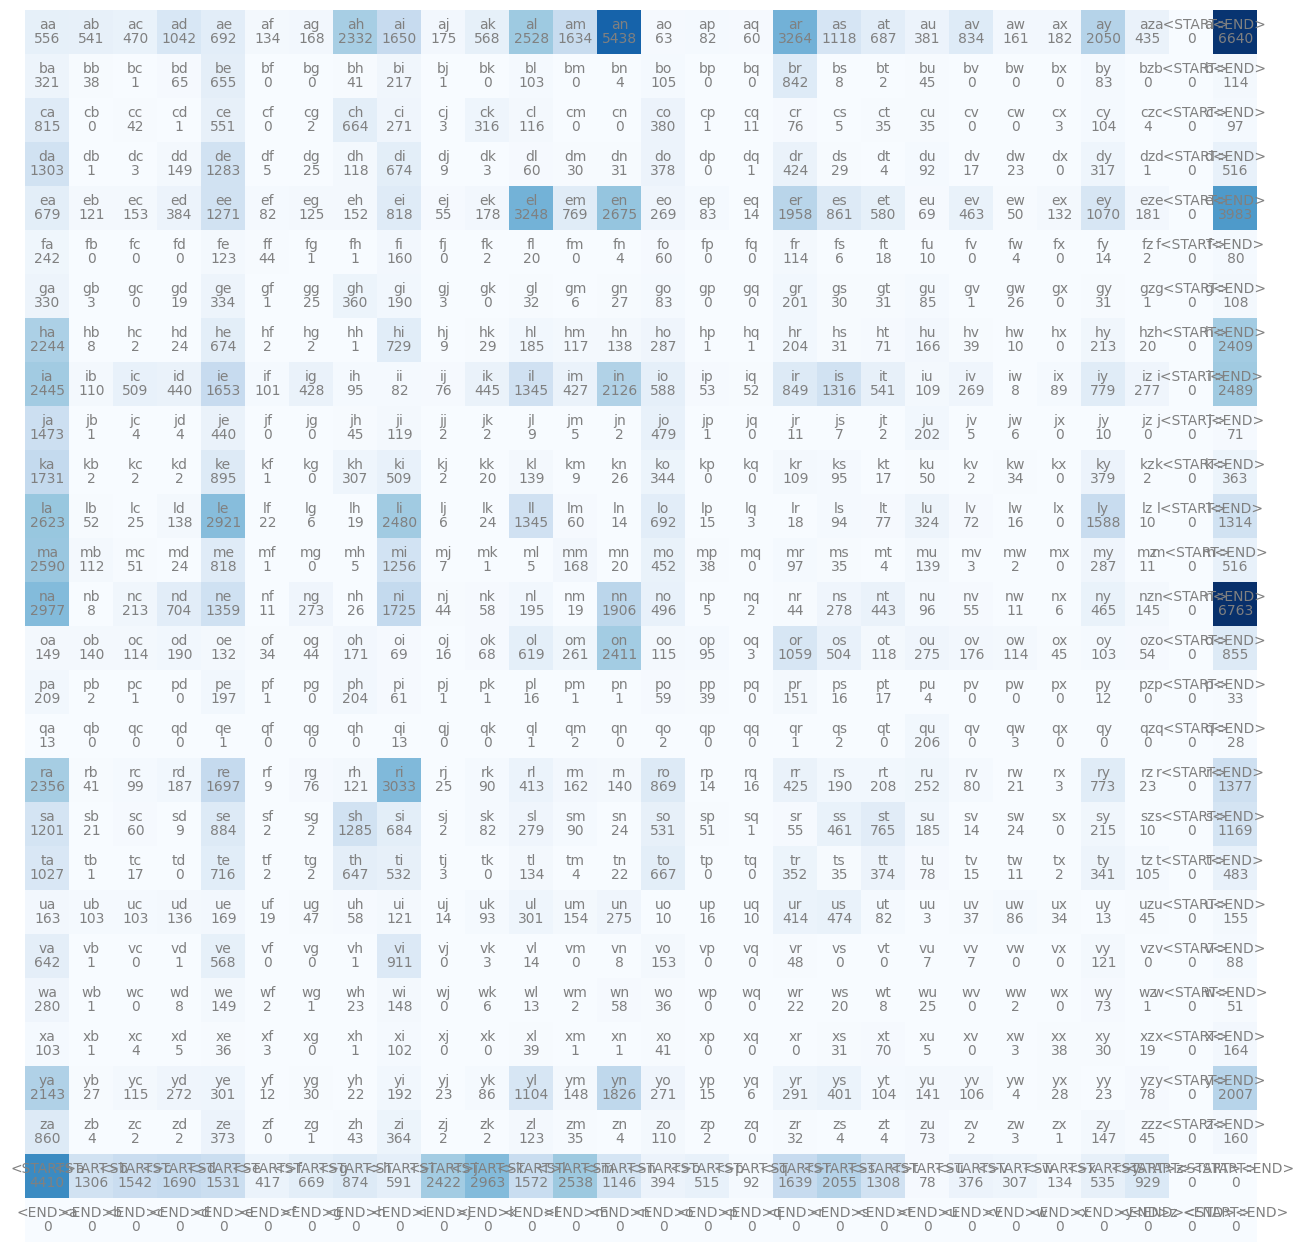

In [31]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(28):
  for j in range(28):
    chstr = itos[i] + itos[j]
    plt.text(j, i , chstr, ha='center', va='bottom', color='gray')
    plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off');

In [32]:
# we dont nee <END>char and char<Start>

In [33]:
N = torch.zeros((27, 27), dtype=torch.int32)
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [34]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ich1 = stoi[ch1]
    ich2 = stoi[ch2]
    N[ich1, ich2] += 1

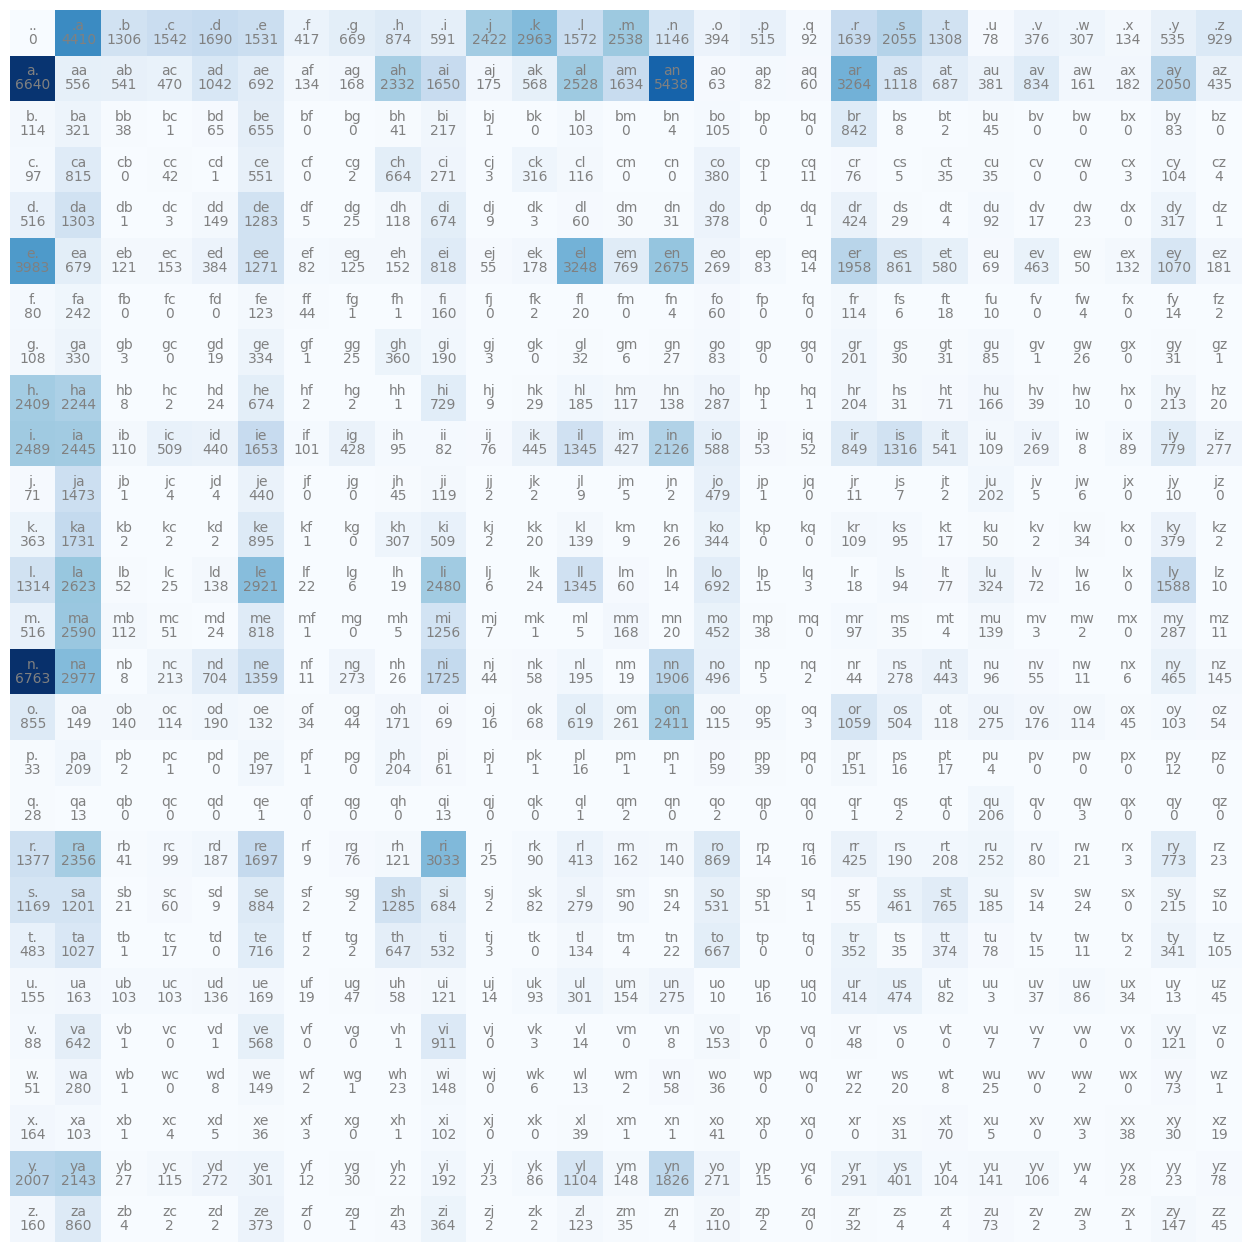

In [35]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i , chstr, ha='center', va='bottom', color='gray')
    plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off');

In [36]:
N[0, :]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [37]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [38]:
# probality distribution
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [39]:
# use generator
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p/p.sum()   #normalizing it
p

tensor([0.6064, 0.3033, 0.0903])

In [40]:
# this number will be same no mater how many time we run it. because we are using teh generator with the seed we aggreed upon

In [41]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [42]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [43]:
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
ix, itos[ix]

(6, 'f')

In [44]:
# here we get 'd' then we will go to 'd' row and check what will come next 'd+char' char --> can be any aplhabet ot '.'(END)

In [45]:
g = torch.Generator().manual_seed(2147483647)
ix = 0
out = []
while True:
  p = N[ix].float()
  p = p/p.sum()
  ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
  if ix == 0:     #i.e '.'(END)
    break
  out.append(itos[ix])
print(''.join(out))

cexze


In [46]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  ix = 0
  out = []
  while True:
    p = N[ix].float()
    p = p/p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    if ix == 0:
      break
    out.append(itos[ix])
  print(''.join(out))

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


In [47]:
for i in range(10):
  g = torch.Generator().manual_seed(2147483647)
  ix = 0
  out = []
  while True:
    p = N[ix].float()
    p = p/p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    if ix == 0:
      break
    out.append(itos[ix])
  print(''.join(out))

cexze
cexze
cexze
cexze
cexze
cexze
cexze
cexze
cexze
cexze


In [48]:
# Explanation

# when g outside the for loop
# ----------------------------------
# Iteration 1 uses the random sequence starting from seed 2147483647 → cexze
# Iteration 2 uses the next random numbers from the same generator → momasurailezitynn
# Iteration 3 uses the next random numbers → konimittain
# and so on.

# seed
#  ↓
# random #1 → cexze
# random #2 → momasurailezitynn
# random #3 → konimittain
# random #4 → llayn
# ...



# When g insode the for loop
# ----------------------------------
# Here, you're creating and seeding a new generator on every iteration.
# So every iteration starts from exactly the same random state:
# Iteration 1:
# seed → random #1 → cexze
# Iteration 2:
# seed → random #1 → cexze
# Iteration 3:
# seed → random #1 → cexze
# ...

In [49]:
# The name does look correct
# because here we are only using 2 char in Bigram

In [50]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  ix = 0
  out = []
  while True:
    p = N[ix].float()
    p = p/p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    if ix == 0:
      break
    out.append(itos[ix])
  print(''.join(out))

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


In [51]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  ix = 0
  out = []
  while True:
    # p = N[ix].float()
    # p = p/p.sum()
    p = torch.ones(27) / 27.0    # Every char is equallly likely here ***************************
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    if ix == 0:
      break
    out.append(itos[ix])
  print(''.join(out))

cexzm
zoglkurkicqzktyhwmvmzimjttainrlkfukzkktda
sfcxvpubjtbhrmgotzx
iczixqctvujkwptedogkkjemkmmsidguenkbvgynywftbspmhwcivgbvtahlvsu
dsdxxblnwglhpyiw
igwnjwrpfdwipkwzkm
desu
firmt
gbiksjbquabsvoth
kuysxqevhcmrbxmcwyhrrjenvxmvpfkmwmghfvjzxobomysox


In [52]:
# So Biagram is performing better than this but not what we are looking for

In [53]:
# Here we are using N[ix].float() then normalizing it (calculating probability) - this is inside while True - its repetative
# so why not we calculate Probality one time and store it in matrix P

In [54]:
P = N.float()

# P.sum()                                                     # tensor(228146.)
# P.sum(0).shape                                              # torch.Size([27])
# P.sum(0, keepdim=True).shape                                # torch.Size([1, 27])
# P.sum(1, keepdim=True).shape                                # torch.Size([27, 1])

# P = P / P.sum(1, keepdim=True)
# Above
# 27, 27
# 27,  1
# This operation is broadcastable
# 27,  1 -- this will be stretches out (copies it) and become 27, 27 - where each column is identical
# Then division happend element wise

# BROADCASTING SEMANTICS  ******************************************************************************** IMP.


# Efficiency TIP **************************************************************************************** efficiency
# P = P / P.sum(1, keepdim=True)
# This creates completely new tensor that we store into P
# We should prefer using **in-place** opertaion
P  /= P.sum(1, keepdim=True)

P[0].sum(), P[5].sum()      # Every row normalize now

(tensor(1.), tensor(1.))

In [55]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  ix = 0
  out = []
  while True:
    # p = N[ix].float()
    # p = p/p.sum()

    p = P[ix]     #****************************

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    if ix == 0:
      break
    out.append(itos[ix])
  print(''.join(out))

cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda


In [56]:
# IMP. **************************************************************************** RESPECT BROADCASTING

# if we dont use 'keepdim = True' by default keepdim=False

# thus
# P.sum(1).shape                        # torch.Size([27])
# P = P / P.sum(1)
# 27, 27
# 27

# steps to boardcasting

# 1. push right
# 27, 27
#     27

# 2. go right to left - number should either 'match', 'one must be 1' or 'one does not exist'
# 27, '27'
#     '27'
# here 27 and 27 up and down are matching, now lets move left

# '27', 27
#       27

# '27', 27
#  '1', 27

# 27, 27
#  1, 27

# then it will make the dim equal by stretching and duplicating
# in this case stretching and duplicating took place vertically (row wise) rather than horizontally (column wise) like when we use keepdim=True

# Thus
# P = P / P.sum(1)
# will
# Normalize the 'P' column wise and not row wise
# P[0].sum() will not be 1
# P[:, 0].sum() will be 1

In [57]:
# evaluate teh quality of the model with the single num

In [58]:
for w in words[:3]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ich1 = stoi[ch1]
    ich2 = stoi[ch2]
    prob = P[ich1, ich2]
    print(f'{ch1}{ch2}: {prob:.4f}')

.e: 0.0478
em: 0.0377
mm: 0.0253
ma: 0.3899
a.: 0.1960
.o: 0.0123
ol: 0.0780
li: 0.1777
iv: 0.0152
vi: 0.3541
ia: 0.1381
a.: 0.1960
.a: 0.1377
av: 0.0246
va: 0.2495
a.: 0.1960


In [59]:
# likelihood = product of probabilities

# we generally work with log(likelihood) as Probalities are between 0 and 1 thus product will be small numeber

# Our goal is to maximize teh likelihood of data w.r.t model parameters = maximize log(likelihood) = minimize -(log(likelihood))

In [60]:
for w in words[:3]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ich1 = stoi[ch1]
    ich2 = stoi[ch2]
    prob = P[ich1, ich2]
    logprob = torch.log(prob)
    print(f'{ch1}{ch2}: {prob:.4f} | {logprob:.4f}')

.e: 0.0478 | -3.0408
em: 0.0377 | -3.2793
mm: 0.0253 | -3.6772
ma: 0.3899 | -0.9418
a.: 0.1960 | -1.6299
.o: 0.0123 | -4.3982
ol: 0.0780 | -2.5508
li: 0.1777 | -1.7278
iv: 0.0152 | -4.1867
vi: 0.3541 | -1.0383
ia: 0.1381 | -1.9796
a.: 0.1960 | -1.6299
.a: 0.1377 | -1.9829
av: 0.0246 | -3.7045
va: 0.2495 | -1.3882
a.: 0.1960 | -1.6299


In [61]:
# log(a*b*c) = log(a) + log(b) + log(c)

In [62]:
log_likelihood = 0.0
for w in words[:3]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ich1 = stoi[ch1]
    ich2 = stoi[ch2]
    prob = P[ich1, ich2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    print(f'{ch1}{ch2}: {prob:.4f} | {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood             # this will be our loss (we want to reduce the loss)
print(f'{nll = }')

.e: 0.0478 | -3.0408
em: 0.0377 | -3.2793
mm: 0.0253 | -3.6772
ma: 0.3899 | -0.9418
a.: 0.1960 | -1.6299
.o: 0.0123 | -4.3982
ol: 0.0780 | -2.5508
li: 0.1777 | -1.7278
iv: 0.0152 | -4.1867
vi: 0.3541 | -1.0383
ia: 0.1381 | -1.9796
a.: 0.1960 | -1.6299
.a: 0.1377 | -1.9829
av: 0.0246 | -3.7045
va: 0.2495 | -1.3882
a.: 0.1960 | -1.6299
log_likelihood=tensor(-38.7856)
nll = tensor(38.7856)


In [63]:
log_likelihood = 0.0
n = 0
for w in words[:3]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ich1 = stoi[ch1]
    ich2 = stoi[ch2]
    prob = P[ich1, ich2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    print(f'{ch1}{ch2}: {prob:.4f} | {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll =}')

#  we avg the nll for convinence
# lower the loss it better our model is
loss = nll/n
print(f'{loss = }')

.e: 0.0478 | -3.0408
em: 0.0377 | -3.2793
mm: 0.0253 | -3.6772
ma: 0.3899 | -0.9418
a.: 0.1960 | -1.6299
.o: 0.0123 | -4.3982
ol: 0.0780 | -2.5508
li: 0.1777 | -1.7278
iv: 0.0152 | -4.1867
vi: 0.3541 | -1.0383
ia: 0.1381 | -1.9796
a.: 0.1960 | -1.6299
.a: 0.1377 | -1.9829
av: 0.0246 | -3.7045
va: 0.2495 | -1.3882
a.: 0.1960 | -1.6299
log_likelihood=tensor(-38.7856)
nll =tensor(38.7856)
loss = tensor(2.4241)


In [64]:
log_likelihood = 0.0
n = 0
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ich1 = stoi[ch1]
    ich2 = stoi[ch2]
    prob = P[ich1, ich2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
nll = -log_likelihood
loss = nll/n
print(f'{loss = }')

loss = tensor(2.4541)


In [65]:
# now lets see if any ch1,ch2 par have zero prod

log_likelihood = 0.0
n = 0
for w in ['andrejq']:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ich1 = stoi[ch1]
    ich2 = stoi[ch2]
    prob = P[ich1, ich2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    print(f'{ch1}{ch2}: {prob:.4f} | {logprob:.4f}')
nll = -log_likelihood
loss = nll/n
print(f'{loss = }')

.a: 0.1377 | -1.9829
an: 0.1605 | -1.8296
nd: 0.0384 | -3.2594
dr: 0.0771 | -2.5620
re: 0.1336 | -2.0127
ej: 0.0027 | -5.9171
jq: 0.0000 | -inf
q.: 0.1029 | -2.2736
loss = tensor(inf)


In [66]:
# loss = inf i.e tis word have 'zero' prod to every occur
# but this is not true - as teh word seems liek a name and all our traning data is name

#  this issue should not occur thus we add a number b to N.
# higher b = more model smoothing (uniform model)
# less b = more peaked model you are going to have

In [67]:
P = (N + 1).float()
P /= P.sum(1, keepdim = True)

In [68]:
log_likelihood = 0.0
n = 0
for w in ['andrejq']:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ich1 = stoi[ch1]
    ich2 = stoi[ch2]
    prob = P[ich1, ich2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    print(f'{ch1}{ch2}: {prob:.4f} | {logprob:.4f}')
nll = -log_likelihood
loss = nll/n
print(f'{loss = }')

.a: 0.1376 | -1.9835
an: 0.1604 | -1.8302
nd: 0.0384 | -3.2594
dr: 0.0770 | -2.5646
re: 0.1334 | -2.0143
ej: 0.0027 | -5.9004
jq: 0.0003 | -7.9817
q.: 0.0970 | -2.3331
loss = tensor(3.4834)


In [69]:
log_likelihood = 0.0
n = 0
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ich1 = stoi[ch1]
    ich2 = stoi[ch2]
    prob = P[ich1, ich2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1

nll = -log_likelihood
loss = nll/n
print(f'{loss = }')

loss = tensor(2.4544)


In [70]:
# nll = negative log likelihood

In [71]:
# Create teh training set for biagram

# /goal = given teh one char predict teh next one

xs, ys = [], []

for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [72]:
# There are 2 types of tensor
# torch.tensor & torch.Tensor
a = torch.tensor([1, 2, 3])
b = torch.Tensor([1, 2, 3])

print(a, b)
print(a.dtype, b.dtype)

# recommended to use smaller t tensor

tensor([1, 2, 3]) tensor([1., 2., 3.])
torch.int64 torch.float32


In [73]:
# we dont feed int to neural network we have to use one hot encoding

import torch.nn.functional as F

In [74]:
F.one_hot(xs, num_classes=27)

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0]])

In [75]:
xenc = F.one_hot(xs, num_classes=27)
yenc = F.one_hot(ys, num_classes=27)

In [76]:
xenc.shape, yenc.shape

(torch.Size([5, 27]), torch.Size([5, 27]))

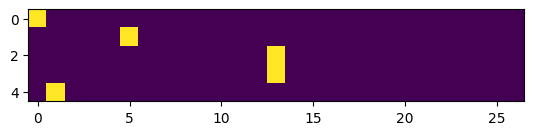

In [77]:
plt.imshow(xenc)

In [78]:
xenc.dtype

torch.int64

In [79]:
#  in neural network we want float not int

xenc = F.one_hot(xs, num_classes=27).float()
yenc = F.one_hot(ys, num_classes=27).float()

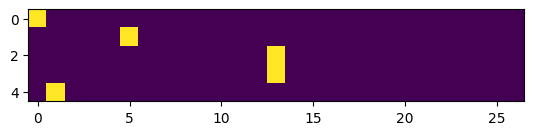

In [80]:
plt.imshow(xenc)

In [81]:
xenc.dtype, yenc.dtype

(torch.float32, torch.float32)

In [82]:
xenc.shape, yenc.shape

(torch.Size([5, 27]), torch.Size([5, 27]))

In [83]:
# weights

W = torch.rand([27, 1])
W

tensor([[0.0872],
        [0.0746],
        [0.8056],
        [0.6503],
        [0.6849],
        [0.7306],
        [0.5997],
        [0.7514],
        [0.0420],
        [0.5593],
        [0.1713],
        [0.5221],
        [0.8281],
        [0.7323],
        [0.2385],
        [0.8665],
        [0.8831],
        [0.9716],
        [0.0864],
        [0.4685],
        [0.3234],
        [0.2618],
        [0.3769],
        [0.6284],
        [0.8882],
        [0.1693],
        [0.3826]])

In [84]:
xenc @ W

tensor([[0.0872],
        [0.7306],
        [0.7323],
        [0.7323],
        [0.0746]])

In [85]:
# [5, 27] @ [27, 1] = [5, 1]

In [86]:
# we do W - [27, 27]

W = torch.rand([27, 27])

xenc @ W

tensor([[0.1526, 0.3341, 0.1138, 0.7368, 0.6280, 0.0781, 0.2286, 0.1542, 0.3929,
         0.8011, 0.8512, 0.1289, 0.3062, 0.3624, 0.2066, 0.4645, 0.8655, 0.7836,
         0.2922, 0.7431, 0.5706, 0.2817, 0.0040, 0.9974, 0.6705, 0.2110, 0.7403],
        [0.2850, 0.2078, 0.2522, 0.1280, 0.1033, 0.1284, 0.8484, 0.3782, 0.8581,
         0.5803, 0.3315, 0.3421, 0.6670, 0.8290, 0.4339, 0.4852, 0.8068, 0.5599,
         0.6053, 0.4532, 0.7675, 0.6791, 0.5852, 0.7993, 0.6005, 0.9326, 0.4889],
        [0.5760, 0.4845, 0.9319, 0.0283, 0.0675, 0.4872, 0.1282, 0.0364, 0.4178,
         0.3977, 0.8113, 0.7879, 0.8063, 0.0739, 0.7663, 0.6349, 0.2714, 0.1876,
         0.9304, 0.1511, 0.7504, 0.9595, 0.9830, 0.8395, 0.1121, 0.7788, 0.9186],
        [0.5760, 0.4845, 0.9319, 0.0283, 0.0675, 0.4872, 0.1282, 0.0364, 0.4178,
         0.3977, 0.8113, 0.7879, 0.8063, 0.0739, 0.7663, 0.6349, 0.2714, 0.1876,
         0.9304, 0.1511, 0.7504, 0.9595, 0.9830, 0.8395, 0.1121, 0.7788, 0.9186],
        [0.2700, 0.3463,

In [87]:
# We want something like probality distribution
# here we can have +ve or -ve numbers
# they are log(count) (assume) so what we will do - we will e^log(x) = x
# this way we will get only +ve numbers

In [88]:
logits = xenc @ W                                 # log counts (interpret)
counts = logits.exp()                             # equivalent to N (interpret)
probs = counts / counts.sum(1, keepdim=True)      # equivalent to P (interpret)
# last 2 line togeter called softmax
probs

tensor([[0.0264, 0.0317, 0.0254, 0.0474, 0.0425, 0.0245, 0.0285, 0.0265, 0.0336,
         0.0506, 0.0532, 0.0258, 0.0308, 0.0326, 0.0279, 0.0361, 0.0539, 0.0497,
         0.0304, 0.0477, 0.0402, 0.0301, 0.0228, 0.0615, 0.0444, 0.0280, 0.0476],
        [0.0283, 0.0262, 0.0274, 0.0242, 0.0236, 0.0242, 0.0498, 0.0311, 0.0503,
         0.0381, 0.0297, 0.0300, 0.0415, 0.0488, 0.0329, 0.0346, 0.0478, 0.0373,
         0.0390, 0.0335, 0.0459, 0.0420, 0.0383, 0.0474, 0.0389, 0.0542, 0.0348],
        [0.0368, 0.0335, 0.0525, 0.0213, 0.0221, 0.0336, 0.0235, 0.0214, 0.0314,
         0.0308, 0.0465, 0.0454, 0.0463, 0.0223, 0.0445, 0.0390, 0.0271, 0.0249,
         0.0524, 0.0240, 0.0438, 0.0539, 0.0552, 0.0478, 0.0231, 0.0450, 0.0518],
        [0.0368, 0.0335, 0.0525, 0.0213, 0.0221, 0.0336, 0.0235, 0.0214, 0.0314,
         0.0308, 0.0465, 0.0454, 0.0463, 0.0223, 0.0445, 0.0390, 0.0271, 0.0249,
         0.0524, 0.0240, 0.0438, 0.0539, 0.0552, 0.0478, 0.0231, 0.0450, 0.0518],
        [0.0281, 0.0303,

In [89]:
probs[0].sum()

tensor(1.)

In [90]:
probs.shape

torch.Size([5, 27])

In [91]:
probs[0].shape

torch.Size([27])

In [92]:
# summary

In [93]:
xs, ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [94]:
# randomly inititing 27 neurons weights
# each neuron have 27 inputs
# thus 27 neuron, each have 27 inputs = 27 x 27 total weights

g = torch.Generator().manual_seed(2147483647)
W = torch.rand([27, 27], generator=g)

In [95]:
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)

In [96]:
probs.shape

torch.Size([5, 27])

In [97]:
# lets calculate loose now

nlls = torch.zeros(5)

for i in range(5):
  x = xs[i].item()
  y = ys[i].item()
  print('\n----------------------------')
  print(f'Bigram ex. {i+1}: {itos[x]}{itos[y]} (index: {x, y})')

  print(f'neural network input: {x}')
  print(f'neural network output: {probs[i]}')

  p = probs[i, y]
  print(f'index of actual next char: {y}')
  print(f'probality of actual next char predicted by neural network: {p.item():.4f}')

  log_likelihood = torch.log(p)
  print(f'log likelihood: {log_likelihood.item():.4f}')

  nll = -log_likelihood   #negative log likelihood
  print(f'negative log_likelihood (nll): {nll.item():.4f}')

  nlls[i] = nll

print('\n===================================')
print(f'loss (average nll): {nlls.mean().item():.4f}')


----------------------------
Bigram ex. 1: .e (index: (0, 5))
neural network input: 0
neural network output: tensor([0.0426, 0.0299, 0.0233, 0.0382, 0.0229, 0.0229, 0.0507, 0.0563, 0.0211,
        0.0280, 0.0440, 0.0313, 0.0497, 0.0439, 0.0308, 0.0261, 0.0424, 0.0563,
        0.0547, 0.0325, 0.0425, 0.0222, 0.0472, 0.0285, 0.0566, 0.0295, 0.0258])
index of actual next char: 5
probality of actual next char predicted by neural network: 0.0229
log likelihood: -3.7751
negative log_likelihood (nll): 3.7751

----------------------------
Bigram ex. 2: em (index: (5, 13))
neural network input: 5
neural network output: tensor([0.0298, 0.0278, 0.0241, 0.0308, 0.0300, 0.0362, 0.0401, 0.0269, 0.0538,
        0.0445, 0.0560, 0.0239, 0.0358, 0.0258, 0.0370, 0.0542, 0.0275, 0.0513,
        0.0263, 0.0253, 0.0315, 0.0294, 0.0317, 0.0507, 0.0554, 0.0562, 0.0380])
index of actual next char: 13
probality of actual next char predicted by neural network: 0.0258
log likelihood: -3.6559
negative log_likelih

In [98]:
# Optimize it now

In [99]:
xs

tensor([ 0,  5, 13, 13,  1])

In [100]:
ys

tensor([ 5, 13, 13,  1,  0])

In [101]:
g = torch.Generator().manual_seed(2147483647)
W = torch.rand([27, 27], generator=g, requires_grad=True)

In [102]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)

In [103]:
# now we have to come up with a way to calculate loss efficiently

In [104]:
probs.shape

torch.Size([5, 27])

In [105]:
probs[0, 5], probs[1, 13], probs[2, 13], probs[3, 1], probs[4, 0]

(tensor(0.0229, grad_fn=<SelectBackward0>),
 tensor(0.0258, grad_fn=<SelectBackward0>),
 tensor(0.0339, grad_fn=<SelectBackward0>),
 tensor(0.0341, grad_fn=<SelectBackward0>),
 tensor(0.0402, grad_fn=<SelectBackward0>))

In [106]:
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [107]:
probs[torch.arange(5), ys]

tensor([0.0229, 0.0258, 0.0339, 0.0341, 0.0402], grad_fn=<IndexBackward0>)

In [108]:
loss = -probs[torch.arange(len(ys)), ys].log().mean()
loss

tensor(3.4815, grad_fn=<NegBackward0>)

In [109]:
# backward pass
W.grad = None     # grad set to zeros
loss.backward()

In [110]:
W.grad

tensor([[ 0.0085,  0.0060,  0.0047,  0.0076,  0.0046, -0.1954,  0.0101,  0.0113,
          0.0042,  0.0056,  0.0088,  0.0063,  0.0099,  0.0088,  0.0062,  0.0052,
          0.0085,  0.0113,  0.0109,  0.0065,  0.0085,  0.0044,  0.0094,  0.0057,
          0.0113,  0.0059,  0.0052],
        [-0.1920,  0.0103,  0.0061,  0.0080,  0.0052,  0.0064,  0.0079,  0.0060,
          0.0062,  0.0110,  0.0094,  0.0080,  0.0078,  0.0094,  0.0116,  0.0077,
          0.0068,  0.0080,  0.0049,  0.0067,  0.0046,  0.0047,  0.0098,  0.0062,
          0.0070,  0.0051,  0.0073],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [111]:
W.grad.shape

torch.Size([27, 27])

In [112]:
# update weights
W.data += -0.1 * W.grad

In [113]:
# as we have update the weights (W) now loss should decrease

logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(len(ys)), ys].log().mean()
loss

tensor(3.4622, grad_fn=<NegBackward0>)

In [114]:
# Lets combine everything

In [115]:
xs, ys = [], []

for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [116]:
g = torch.Generator().manual_seed(2147483647)
W = torch.rand([27, 27], generator=g, requires_grad=True)
xenc = F.one_hot(xs, num_classes=27).float()

In [117]:
# forward pass
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(len(ys)), ys].log().mean()
loss

tensor(3.4815, grad_fn=<NegBackward0>)

In [118]:
torch.set_printoptions(precision=4, sci_mode=False)         # will display all tensor in round(4)

n = 0
while loss.item() > 0.3:

  # forward pass
  logits = xenc @ W
  counts = logits.exp()
  probs = counts / counts.sum(1, keepdim=True)
  loss = -probs[torch.arange(len(ys)), ys].log().mean() + 0.001 * (W**2).mean()

  # adding regularization
  # this will try to push W to zeo which will result in smotthing of probality distribution
  #  W = 0 --> logits = 0 --> counts = 1 --> probs = equally distributed

  # backward
  W.grad = None     # grad set to zeros
  loss.backward()

  # update weights
  W.data += -1 * W.grad

  n += 1

  # print(f'iteration: {n}')
  # print(f'current loss: {loss}')

print(f'total iterations: {n}')
print(f'final loss: {loss}\n')

print(ys)
print(probs)
print(torch.argmax(probs, dim=1))

total iterations: 244
final loss: 0.2999773919582367

tensor([ 5, 13, 13,  1,  0])
tensor([[0.0010, 0.0007, 0.0006, 0.0009, 0.0006, 0.9775, 0.0011, 0.0012, 0.0006,
         0.0007, 0.0010, 0.0008, 0.0011, 0.0010, 0.0008, 0.0007, 0.0010, 0.0012,
         0.0012, 0.0008, 0.0010, 0.0006, 0.0010, 0.0007, 0.0012, 0.0007, 0.0007],
        [0.0007, 0.0007, 0.0006, 0.0008, 0.0007, 0.0009, 0.0009, 0.0007, 0.0011,
         0.0010, 0.0012, 0.0006, 0.0008, 0.9775, 0.0009, 0.0011, 0.0007, 0.0011,
         0.0007, 0.0006, 0.0008, 0.0007, 0.0008, 0.0011, 0.0012, 0.0012, 0.0009],
        [0.0008, 0.4895, 0.0009, 0.0008, 0.0008, 0.0006, 0.0006, 0.0007, 0.0010,
         0.0011, 0.0010, 0.0007, 0.0010, 0.4895, 0.0010, 0.0010, 0.0006, 0.0008,
         0.0008, 0.0011, 0.0006, 0.0010, 0.0007, 0.0006, 0.0011, 0.0008, 0.0010],
        [0.0008, 0.4895, 0.0009, 0.0008, 0.0008, 0.0006, 0.0006, 0.0007, 0.0010,
         0.0011, 0.0010, 0.0007, 0.0010, 0.4895, 0.0010, 0.0010, 0.0006, 0.0008,
         0.0008, 0.0011

In [119]:
# for all words

xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
print(f'xs shape = {xs.shape}')
print(f'ys shape = {ys.shape}\n')

g = torch.Generator().manual_seed(2147483647)
W = torch.rand([27, 27], generator=g, requires_grad=True)
xenc = F.one_hot(xs, num_classes=27).float()

# forward pass
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(len(ys)), ys].log().mean()

torch.set_printoptions(precision=4, sci_mode=False)         # will display all tensor in round(4)

n = 0
while n < 100:
  # forward pass
  logits = xenc @ W
  counts = logits.exp()
  probs = counts / counts.sum(1, keepdim=True)
  loss = -probs[torch.arange(len(ys)), ys].log().mean() + 0.001 * (W**2).mean()
  # backward
  W.grad = None     # grad set to zeros
  loss.backward()
  # update weights
  W.data += -50 * W.grad
  n += 1
print(f'total iterations: {n}')
print(f'final loss: {loss}\n')
print(ys)
print(probs)
print(torch.argmax(probs, dim=1))

xs shape = torch.Size([228146])
ys shape = torch.Size([228146])

total iterations: 100
final loss: 2.472614288330078

tensor([ 5, 13, 13,  ..., 26, 24,  0])
tensor([[0.0013, 0.1376, 0.0407,  ..., 0.0043, 0.0166, 0.0289],
        [0.1948, 0.0331, 0.0058,  ..., 0.0064, 0.0522, 0.0087],
        [0.0748, 0.3872, 0.0132,  ..., 0.0034, 0.0397, 0.0040],
        ...,
        [0.2043, 0.2182, 0.0039,  ..., 0.0045, 0.0038, 0.0077],
        [0.0520, 0.3505, 0.0074,  ..., 0.0074, 0.0470, 0.0162],
        [0.1843, 0.1120, 0.0262,  ..., 0.0302, 0.0299, 0.0361]],
       grad_fn=<DivBackward0>)
tensor([1, 0, 1,  ..., 1, 1, 0])


In [120]:
# lets compare before method and this menthod

g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  ix = 0
  out = []

  while True:

    # BEFORE
    p = P[ix]

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])

    if ix == 0:
      break

  print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [121]:
# lets compare before method and this menthod

g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  ix = 0
  out = []

  while True:

    # CURRENT
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    p = counts / counts.sum(1, keepdim=True)

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])

    if ix == 0:
      break

  print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
